In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import sys
sys.path.insert(0, '../../Functions')
from plot_placement import  plot_song_prediction_comparison

ImportError: cannot import name 'plot_song_prediction_comparison' from 'plot_placement' (c:\Users\Marcel\OneDrive\Pulpit\Python\inzynierka\ML\Forecast\../../Functions\plot_placement.py)

In [54]:
data = pd.read_csv("../../Data/processed_forecast_data.csv")


data.head()

,Date,Song,Artist,Rank,Last Week,Weeks in Charts,Normalized Title,Danceability,Energy,Key,...,Duration_ms,Time_signature,Chorus_hit,Sections,rank_change,target_next_rank,rolling_avg_4_weeks,rolling_avg_all_time,rolling_std_4_weeks,rolling_std_all_time
0,1958-12-17,Jingle Bell Rock,Bobby Helms,57,NaN,NaN,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,NaN,35.0,57.000000,57.000000,NaN,NaN
1,1958-12-24,Jingle Bell Rock,Bobby Helms,35,57.0,2.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,22.0,45.0,46.000000,46.000000,15.556349,15.556349
2,1958-12-31,Jingle Bell Rock,Bobby Helms,45,35.0,3.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,-10.0,70.0,45.666667,45.666667,11.015141,11.015141
3,1959-01-07,Jingle Bell Rock,Bobby Helms,70,45.0,4.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,-25.0,69.0,51.750000,51.750000,15.129992,15.129992
4,1960-12-07,Rockin' Around The Christmas Tree,Brenda Lee,64,NaN,NaN,rockin around the christmas tree,0.589,0.472,8,...,126267,4,33.91817,6,NaN,26.0,64.000000,64.000000,NaN,NaN


In [57]:
# Currently reduce audio features to the most important ones based on feature importance from previous classification model, to see if it improves forecasting performance. Will experiment with adding more features later.
all_audio_features = ['Instrumentalness', 'Danceability', 'Acousticness', 'Duration_ms', 'Energy', 'Valence', 'Loudness', 'Speechiness', 'Key', 'Mode', 'Time_signature']
audio_features = ['Instrumentalness', 'Danceability', 'Acousticness', 'Duration_ms', 'Energy', 'Valence']
all_features = ['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Weeks in Charts', 'Normalized Title', 'rank_change', 'rolling_avg_4_weeks', 'rolling_avg_all_time', 'rolling_std_4_weeks', 'rolling_std_all_time', 'target_next_rank'] + all_audio_features

In [58]:
data = data[all_features]

In [59]:
data.head()

,Date,Song,Artist,Rank,Last Week,Weeks in Charts,Normalized Title,rank_change,rolling_avg_4_weeks,rolling_avg_all_time,...,Danceability,Acousticness,Duration_ms,Energy,Valence,Loudness,Speechiness,Key,Mode,Time_signature
0,1958-12-17,Jingle Bell Rock,Bobby Helms,57,NaN,NaN,jingle bell rock,NaN,57.000000,57.000000,...,0.754,0.643,130973,0.424,0.806,-8.463,0.0363,2,1,4
1,1958-12-24,Jingle Bell Rock,Bobby Helms,35,57.0,2.0,jingle bell rock,22.0,46.000000,46.000000,...,0.754,0.643,130973,0.424,0.806,-8.463,0.0363,2,1,4
2,1958-12-31,Jingle Bell Rock,Bobby Helms,45,35.0,3.0,jingle bell rock,-10.0,45.666667,45.666667,...,0.754,0.643,130973,0.424,0.806,-8.463,0.0363,2,1,4
3,1959-01-07,Jingle Bell Rock,Bobby Helms,70,45.0,4.0,jingle bell rock,-25.0,51.750000,51.750000,...,0.754,0.643,130973,0.424,0.806,-8.463,0.0363,2,1,4
4,1960-12-07,Rockin' Around The Christmas Tree,Brenda Lee,64,NaN,NaN,rockin around the christmas tree,NaN,64.000000,64.000000,...,0.589,0.614,126267,0.472,0.898,-8.749,0.0502,8,1,4


In [60]:
#Check final date in the dataset
data['Date'] = pd.to_datetime(data['Date'])
print(data['Date'].max())
#Split data into train and test based on date, using 2014 as the cutoff date, as we want to forecast 2015 to 2025
train_data = data[data['Date'] < '2014-01-01']
test_data = data[data['Date'] >= '2014-01-01']
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Train data is {round(len(train_data)/len(data)*100, 2)}% of the total data")


2025-07-30 00:00:00
Train data shape: (105382, 24)
Test data shape: (27083, 24)
Train data is 79.55% of the total data


FIRST XGBOOST

In [63]:
features = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + audio_features

In [64]:
y = data['target_next_rank']
X = data[features]

In [65]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [66]:
model.fit(X, y)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
# Get feature importance
feature_importance = model.feature_importances_
# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)
print(importance_df)

                 Feature  Importance
0                   Rank    0.543325
1              Last Week    0.331583
3            rank_change    0.044168
4    rolling_avg_4_weeks    0.041888
2        Weeks in Charts    0.008702
5   rolling_avg_all_time    0.007939
6    rolling_std_4_weeks    0.006298
7   rolling_std_all_time    0.003351
11           Duration_ms    0.002573
13               Valence    0.002284
9           Danceability    0.002093
12                Energy    0.001977
8       Instrumentalness    0.001976
10          Acousticness    0.001845


In [70]:
#Check JUST the audio features importance
audio_importance_df = importance_df[importance_df['Feature'].isin(all_audio_features)].sort_values(by='Importance', ascending=False)
print(audio_importance_df)

             Feature  Importance
11       Duration_ms    0.002573
13           Valence    0.002284
9       Danceability    0.002093
12            Energy    0.001977
8   Instrumentalness    0.001976
10      Acousticness    0.001845


In [86]:
#Check model RMSE on the test set
from sklearn.metrics import mean_squared_error
X_test = test_data[features]
y_test = test_data['target_next_rank']
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse}")


Test RMSE: 8.467477645406928


In [93]:
test_data[test_data['Song'] == 'Royals']

,Date,Song,Artist,Rank,Last Week,Weeks in Charts,Normalized Title,rank_change,rolling_avg_4_weeks,rolling_avg_all_time,...,Danceability,Acousticness,Duration_ms,Energy,Valence,Loudness,Speechiness,Key,Mode,Time_signature
105386,2014-01-01,Royals,Lorde,5,5.0,25.0,royals,0.0,4.25,16.840000,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
105475,2014-01-08,Royals,Lorde,4,5.0,26.0,royals,1.0,4.50,16.346154,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
105564,2014-01-15,Royals,Lorde,4,4.0,27.0,royals,0.0,4.50,15.888889,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
105656,2014-01-22,Royals,Lorde,7,4.0,28.0,royals,-3.0,5.00,15.571429,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
105743,2014-01-29,Royals,Lorde,7,7.0,29.0,royals,0.0,5.50,15.275862,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
105831,2014-02-05,Royals,Lorde,9,7.0,30.0,royals,-2.0,6.75,15.066667,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
105920,2014-02-12,Royals,Lorde,9,9.0,31.0,royals,0.0,8.00,14.870968,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
106013,2014-02-19,Royals,Lorde,12,9.0,32.0,royals,-3.0,9.25,14.781250,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
106103,2014-02-26,Royals,Lorde,14,12.0,33.0,royals,-2.0,11.00,14.757576,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4
106191,2014-03-05,Royals,Lorde,17,14.0,34.0,royals,-3.0,13.00,14.823529,...,0.674,0.121,190185,0.428,0.337,-9.504,0.122,7,1,4


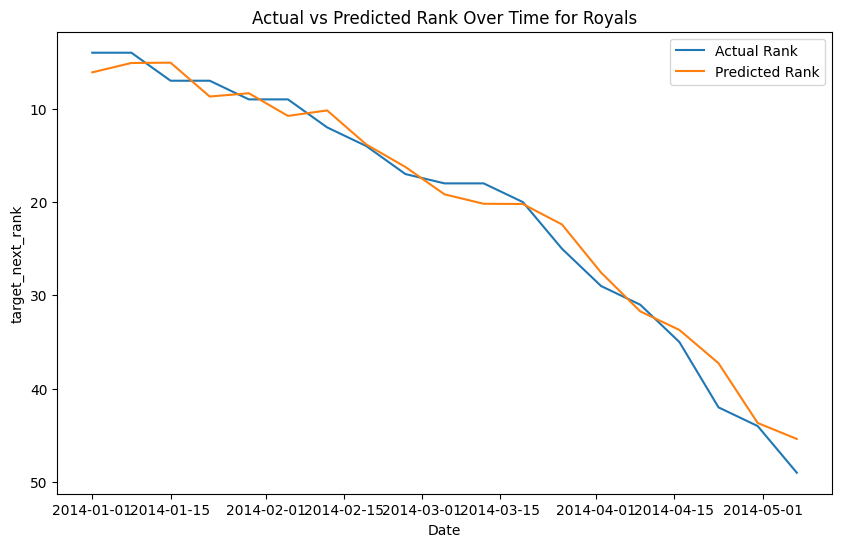

In [ ]:
#put y_pred back into the test_data for easier plotting

#plot example song placement with actual vs predicted rank

#plot example song placement with actual vs predicted rank

plot_song_prediction_comparison(test_data, 'Royals', y_pred)